In [ ]:
from langgraph.graph import StateGraph,START,END
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage,SystemMessage,BaseMessage
from langgraph.graph.message import add_messages

from langgraph.prebuilt import ToolNode,tools_condition
from ddgs import DDGS
from langchain_core.tools import tool

from dotenv import load_dotenv
from typing import TypedDict,Annotated

import requests
import random
import json


In [3]:
load_dotenv()
llm = ChatOpenAI()

In [ ]:
# tools creation
api_key = "<<API_KEY_FOR_STOCK>>"
@tool
def search_tool(query: str) -> str:
    """DuckDuckGoSearchRun module to search any query over web and provide the response back."""
    with DDGS() as ddgs:
        results = ddgs.text(query, max_results=5)
        if not results:
            return "No results found."
        return "\n\n".join(
            f"Title: {r['title']}\nURL: {r['href']}\nSummary: {r['body']}"
            for r in results
        )
        
@tool
def calculator(first_number: float , second_number: float , operator: str) -> float:
    """Perform basic arithmetic operation on two numbers.
    Supported Operations are: add , sub, mul, div
    """
    if operator.lower() == "add":
        result = first_number + second_number
    elif operator.lower() == "sub":
        result = first_number - second_number
    elif operator.lower() == "mul":
        result = first_number * second_number
    elif operator.lower() == "div":
        if second_number == 0:
            return {"error" : "Division by Zero is not allowed."}
        result = first_number / second_number
    else:
        return {"error" : f"Unsupported arithmetic operation {operator}"}
        
    return {"first_number": first_number,"second_number": second_number,"operator": operator,"result" : result}

@tool
def get_stock_price(company_symbol:str) -> float:
    """Function to retrieve latest stock price for given company symbol"""
    url = f'https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={company_symbol}&apikey=<<api_key>>'
    
    result = requests.get(url).json()
    
    return result #{"company_symbol": company_symbol, "result": result}

In [5]:
tools = [search_tool,get_stock_price,calculator]

llm_with_tools = llm.bind_tools(tools)

In [6]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage],add_messages]

In [7]:
def chatNode(state: ChatState) -> ChatState:
    messages = state.get("messages")
    result = llm_with_tools.invoke(messages)
    return {"messages" : [result]}
    

tool_node = ToolNode(tools)

In [8]:
graph = StateGraph(ChatState)

graph.add_node("chatNode",chatNode)
graph.add_node("tools",tool_node)

graph.add_edge(START,"chatNode")
graph.add_conditional_edges("chatNode",tools_condition)

graph.add_edge("tools","chatNode")
chatbot = graph.compile()

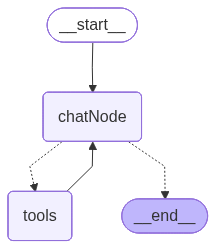

In [9]:
chatbot

In [10]:
response = chatbot.invoke({"messages": [HumanMessage(content="Hello")]})

In [11]:
print(response["messages"][-1].content)

Hi there! How can I assist you today?


In [16]:
response = chatbot.invoke({"messages": [HumanMessage(content="What is 2*3?")]})
print(response["messages"][-1].content)

The result of 2 multiplied by 3 is 6.


In [17]:
response = chatbot.invoke({"messages": [HumanMessage(content="What is current market price of Oracle?")]})
print(response["messages"][-1].content)

The current market price of Oracle (ORCL) is $143.66.


In [18]:
response = chatbot.invoke({"messages": [HumanMessage(content="What is current market price of Oracle? how much amount for 500 oracle shares?")]})
print(response["messages"][-1].content)

The current market price of Oracle (ORCL) is $143.66 per share. 

The amount for 500 Oracle shares would be $71,830.
